# Iterative quantum phase estimation

<div style="border-left:4px solid #6d3f8c;background:#6d3f8c1a;border-radius:4px;margin:1em 0;"><div style="background:#6d3f8c;color:#ffffff;padding:0.35em 0.8em;font-weight:600;">Chapter focus</div>

<div style="padding:0.1em 1em;">

How do we extract the molecular ground-state energy from the prepared quantum state?

</div>

</div>

## Learning objectives

After completing this chapter, you will be able to:

- Relate a Hamiltonian eigenvalue to a time-evolution eigenphase.
- Describe how IQPE measures phase bits.
- Explain the roles of the compute register and readout ancilla.
- Relate phase bits, shots per bit, and repeated complete runs to the energy estimate.
- Run IQPE with native QDK/Chemistry tools.
- Reconstruct the total molecular energy and evaluate its error.

<div style="border-left:4px solid #005a8d;background:#005a8d1a;border-radius:4px;margin:1em 0;"><div style="background:#005a8d;color:#ffffff;padding:0.35em 0.8em;font-weight:600;">Lab notebook assignment</div>

<div style="padding:0.1em 1em;">

Complete *lab notebook phase estimation* and *lab notebook conclusion*.
Record the algorithm settings before starting the final simulation and record the measured values after it finishes.
Use the completed lab notebook to explain whether the result meets the teaching target and which chemistry and algorithm limitations remain.

</div>

</div>

## Before you begin

This course requires a Python environment with the `qdk-chemistry[jupyter]` package.

`qdk-chemistry` ships compiled binaries for Linux, macOS on Apple silicon, and Windows on x86-64. On Windows on Arm, run this course inside WSL. Run the cell below to check the current environment.

In [ ]:
from _unit import check_env

check_env()

## Setting up

The cell below imports the QDK/Chemistry pieces this chapter uses and quiets the solver logs.

In [ ]:
from collections import Counter
from dataclasses import dataclass
from time import perf_counter

import numpy as np
from qdk_chemistry.algorithms import create
from qdk_chemistry.data import AlgorithmRef, Circuit, QubitOperator
from qdk_chemistry.utils import Logger
from tutorial_map_n2_to_qubits import QubitMappingResult, run_qubit_mapping_workflow
from tutorial_prepare_trial_state import TrialStateResult, run_trial_state_workflow

DEFAULT_NUM_PHASE_BITS = 6
DEFAULT_SHOTS_PER_BIT = 3
DEFAULT_NUM_COMPLETE_RUNS = 20
DEFAULT_FIRST_SEED = 42
TARGET_ENERGY_ERROR_HARTREE = 1e-3

@dataclass
class EvolutionTimeChoice:
    r"""Intermediate and final values in reference-guided time selection.

    Attributes:
        bound_time_hartree_inverse: Initial time :math:`\pi/\lambda`, in inverse
            Hartree, whose signed phase interval contains the bounded spectrum.
        bound_reference_phase_fraction: Reference phase fraction at the bound time.
        time_hartree_inverse: Final adjusted evolution time in inverse Hartree.
        reference_phase_fraction: Reference phase fraction at the adjusted time.
        grid_phase_fraction: Selected finite-bit phase-grid fraction.
        grid_bitstring: Most-significant-bit-first representation of that fraction.
        grid_active_energy_hartree: Active-space energy reconstructed from the
            selected grid point, in Hartree.
    """

    bound_time_hartree_inverse: float
    bound_reference_phase_fraction: float
    time_hartree_inverse: float
    reference_phase_fraction: float
    grid_phase_fraction: float
    grid_bitstring: str
    grid_active_energy_hartree: float

@dataclass
class IqpeProblem:
    """Prepared Hamiltonian, trial state, controls, and iteration circuits.

    Attributes:
        mapping: Selected-space fermion-to-qubit mapping result.
        trial_state: Selected trial-state and preparation circuit.
        evolution_time: Reference-guided phase-grid/time selection.
        num_phase_bits: Number of bitwise IQPE iterations.
        shots_per_bit: Simulator executions used for each bit majority vote.
        circuit_builder_reference: Serializable nested algorithm configuration
            supplied to the phase-estimation implementation.
        iteration_circuits: Constructed circuits in controlled-power order; the
            list length equals ``num_phase_bits``.
    """

    mapping: QubitMappingResult
    trial_state: TrialStateResult
    evolution_time: EvolutionTimeChoice
    num_phase_bits: int
    shots_per_bit: int
    circuit_builder_reference: AlgorithmRef
    iteration_circuits: list[Circuit]

@dataclass
class IqpeRun:
    """Measurements, energies, and timing from one complete bitwise IQPE run.

    Attributes:
        seed: Full-state simulator seed.
        bitstring: Canonical most-significant-bit-first phase-grid label.
        phase_fraction: Measured phase fraction in ``[0, 1)``.
        active_energy_hartree: Eigenvalue returned for the qubit Hamiltonian.
        total_energy_hartree: Active energy plus the classically stored core energy.
        error_hartree: Total energy minus the selected-space CASCI reference.
        runtime_seconds: Wall-clock simulator time for this complete six-bit run.
    """

    seed: int
    bitstring: str
    phase_fraction: float
    active_energy_hartree: float
    total_energy_hartree: float
    error_hartree: float
    runtime_seconds: float

@dataclass
class IqpeWorkflowResult:
    """Repeated IQPE results and their unique modal estimate.

    Attributes:
        problem: Shared problem definition used for every repeated run.
        runs: Complete-run results in seed order.
        bitstring_counts: Frequency of each observed complete bitstring.
        modal_run: First run carrying the unique most frequent bitstring.
        total_runtime_seconds: Wall-clock duration of the repeated-run phase.
    """

    problem: IqpeProblem
    runs: list[IqpeRun]
    bitstring_counts: dict[str, int]
    modal_run: IqpeRun
    total_runtime_seconds: float

from tutorial_prepare_trial_state import circuit_statistics
from tutorial_run_iqpe import (
    prepare_iqpe_problem,
    print_iqpe_results,
    run_iqpe_workflow,
)

## Prerequisite concepts

An IQPE calculation requires four kinds of information:

- ***Qubit Hamiltonian***
  A Hermitian operator whose eigenvalue is sought, represented on the compute register.
- ***Trial state***
  A normalized state with nonzero weight on the target Hamiltonian eigenstate.
- ***Time-evolution implementation***
  A logical circuit approximating $e^{-i\hat Ht}$ and controlled powers of that unitary.
- ***Numerical and sampling controls***
  An evolution time, number of phase bits, shots per bit, and number of complete runs.

The previous chapters supplied the qubit Hamiltonian and trial state for the selected molecular problem.
They also recorded the core energy needed to reconstruct the molecular total and the classical CASCI reference used to validate the final estimate; those two quantities are bookkeeping and validation data rather than inputs to the phase-estimation circuit.

The compute register stores the encoded active-space wavefunction.
This chapter adds one readout ancilla, a qubit used to extract phase information without representing another spin orbital.
The [quantum phase estimation overview](https://en.wikipedia.org/wiki/Quantum_phase_estimation_algorithm) provides an optional refresher on the basic controlled-unitary circuit model.

## Energy-to-phase encoding

Let $\vert\Psi_j\rangle$ be an eigenstate of the qubit Hamiltonian with active-space energy $E_j$:

$$
\hat H_{\mathrm{qubit}}\vert\Psi_j\rangle
= E_j\vert\Psi_j\rangle.
$$

In atomic units, the evolution time $t$ is expressed in inverse Hartree, $E_{\mathrm{h}}^{-1}$, so the product $E_jt$ is dimensionless.
The time-evolution unitary is

$$
U(t)=e^{-i\hat H_{\mathrm{qubit}}t}.
$$

Because every power of the Hamiltonian acting on $\vert\Psi_j\rangle$ contributes the corresponding power of $E_j$, the exponential acts on that eigenstate as

$$
U(t)\vert\Psi_j\rangle
=e^{-i\hat H_{\mathrm{qubit}}t}\vert\Psi_j\rangle
=e^{-iE_jt}\vert\Psi_j\rangle.
$$

The physical eigenphase in the exponential is therefore $-E_jt$ modulo $2\pi$.
The phase fraction reported by QPE is

$$
\varphi_j
=\left(\frac{-E_jt}{2\pi}\right)\bmod 1.
$$

The QDK/Chemistry result object handles the modulo wrapping automatically.
It converts the measured phase fraction to a signed angle $\alpha\in(-\pi,\pi]$ and returns $-\alpha/t$.
The tutorial script uses this value directly rather than manually applying a sign conversion.
To avoid aliasing, the active-space Hamiltonian energy eigenvalue $E_j$ being estimated must lie in the signed interval $[-\pi/t,\pi/t)$; energies outside that interval can produce the same measured phase.
The two boundary energies differ by one complete phase turn and therefore represent the same measured phase; QDK/Chemistry assigns that boundary to $-\pi/t$.

The next figure shows how to read this wrapping convention.
Follow the upper axis from $\varphi=0$ toward $\varphi=1$.
From zero through one half, the signed angle is nonnegative, so $E=-\alpha/t$ runs from zero down to $-\pi/t$ along the green branch.
Immediately above one half, the signed angle wraps from $+\pi$ to just above $-\pi$; the corresponding energy jumps to just below $+\pi/t$ and then returns toward zero along the purple branch.
At $\varphi=1/2$, the lower filled point includes $-\pi/t$, while the upper open point excludes the equivalent $+\pi/t$ representation.

<div style="text-align:center;">

![Signed reconstructed energy plotted against phase fraction from zero to one. Phase fractions from zero through one half map from zero down to minus pi over t. Immediately above one half, the signed branch wraps to just below plus pi over t and returns toward zero as the phase approaches one. A neutral dashed guide connects the included minus pi over t point and excluded plus pi over t point at phase one half. A red bracket beside the plot spans their energy difference of two pi over t. Phase one wraps to phase zero.](attachment:tutorial_qpe_phase_wrapping.png)

*QDK/Chemistry converts the wrapped phase fraction to one signed energy branch. The neutral dashed guide marks the shared phase $\varphi=1/2$; the red bracket spans the $2\pi/t$ energy difference between its included and excluded boundary representations. Energies separated by that amount alias to the same reported phase.*

</div>

With $m$ measured phase bits, the representable fractions are multiples of $2^{-m}$, so adjacent energy-grid points are separated by

$$
\Delta E_{\mathrm{grid}}=\frac{2\pi}{t2^m}.
$$

With $m$ measured phase bits, the largest controlled power is $U^{2^{m-1}}$.
Increasing $m$ from six to ten therefore raises the largest power from $U^{32}$ to $U^{512}$, increasing the size and runtime cost of the largest iteration circuit by a factor of sixteen for this repeated-power strategy.
This tutorial uses six bits to keep the simulation tractable; that choice does not by itself provide $\mathrm{m}E_{\mathrm{h}}$ resolution.

The evolution time is computed from quantities already produced by the classically tractable example chosen for this tutorial.
If we write the mapped Hamiltonian as $\hat H_{\mathrm{qubit}}=\sum_\ell h_\ell P_\ell$ and define

$$
\lambda=\sum_\ell\lvert h_\ell\rvert.
$$

The QDK/Chemistry application programming interface (API) exposes this coefficient 1-norm as `qubit_hamiltonian.schatten_norm`; the tutorial script uses it to choose the evolution time and reports it in the pre-simulation settings.
For this Hamiltonian, the reported value is $\lambda=19.610172748837\ E_{\mathrm{h}}$.
Because $\lambda$ bounds the magnitudes of the Hamiltonian eigenvalues, the initial choice

$$
t_{\mathrm{bound}}=\frac{\pi}{\lambda}
=0.160202191680\ E_{\mathrm{h}}^{-1}
$$

keeps the spectrum within the signed, unaliased phase interval.
The script reports this value as the `Initial unaliased time bound` in its pre-simulation settings.
Using the active-space reference from *Mapping the problem to qubits*, $E_{\mathrm{ref}}=-9.653276065987\ E_{\mathrm{h}}$, this initial time gives the implementation phase fraction

$$
\varphi_{\mathrm{bound}}
=\left(\frac{-t_{\mathrm{bound}}E_{\mathrm{ref}}}{2\pi}\right)\bmod 1
\approx0.246129297014.
$$

The script reports this value as the `Reference phase at initial time bound`.
The nearest six-bit fraction is $16/64=0.25$, represented by `010000`.
Its signed angle is $2\pi(16/64)=+\pi/2$.
Finally, we can choose the evolution time so that this grid point reconstructs an energy $\delta=0.001\ E_{\mathrm{h}}$ above the known reference:

$$
t
=\frac{-\pi/2}{E_{\mathrm{ref}}+\delta}
=0.162738437655\ E_{\mathrm{h}}^{-1}.
$$

The script reports this adjusted value as the `Selected evolution time`.
Using this time, the reference phase fraction is approximately $0.250025901$, only about $2.59\times10^{-5}$ above the selected grid point.
The grid point therefore reconstructs an active energy exactly $1\ \mathrm{m}E_{\mathrm{h}}$ above the classical reference to the displayed precision.

The table below compares the selected point with its neighboring six-bit grid energies and the known reference.
The rows are ordered by energy rather than by grid index, so the more negative $k=17$ energy appears before $k=16$.
The reference row has no grid index or bitstring because the reference does not lie exactly on the six-bit grid.

<div style="display:flex;flex-direction:column;align-items:center;">

| Grid point | Bitstring | Active energy ($E_{\mathrm{h}}$) |
|---|---|---|
| $k=17$ | `010001` | $-10.255543320111$ |
| Known reference (not a grid point) | Not applicable | $-9.653276065987$ |
| $k=16$ (selected) | `010000` | $-9.652276065987$ |
| $k=15$ | `001111` | $-9.049008811863$ |

*Six-bit active-energy grid near the reference. Here $k$ is the integer grid index, so $\varphi_k=k/2^6=k/64$; its six-bit binary representation is the measured bitstring.*

</div>

The neighboring grid energies differ by approximately $0.6033\ E_{\mathrm{h}}$.
By contrast, selected grid point $k=16$ is only $0.001\ E_{\mathrm{h}}$ above the known reference.
This small offset is possible because the evolution time was tuned using that reference; it is not the general resolution of the six-bit grid.

**Please note**: this use of the already known classical energy is circular.
It is useful for this tutorial, but it is not a generally available strategy when the target energy is unknown.
For the chosen $t$, adjacent energies represented by the six-bit phase grid differ by approximately $0.6033\ E_{\mathrm{h}}$, not $0.001\ E_{\mathrm{h}}$.
The smaller value, $0.001\ E_{\mathrm{h}}$ or $1\ \mathrm{m}E_{\mathrm{h}}$, is the accuracy target adopted for this tutorial.
The question below asks why one grid point can nevertheless reconstruct this particular reference energy within that target.

<div style="border-left:4px solid #8c4a00;background:#8c4a001a;border-radius:4px;margin:1em 0;"><details><summary style="background:#8c4a00;color:#ffffff;padding:0.35em 0.8em;cursor:pointer;font-weight:600;">&#10067;&nbsp;Why does six-bit phase estimation meet a $1\ \mathrm{m}E_{\mathrm{h}}$ target here even though adjacent grid points are much farther apart?</summary>

<div style="padding:0.1em 1em;">

The classically known reference energy was used to tune the evolution time so the target lies almost exactly on one six-bit grid point.
Six bits do not provide $\mathrm{m}E_{\mathrm{h}}$ resolution for arbitrary energies with this evolution time.

</div>

</details></div>
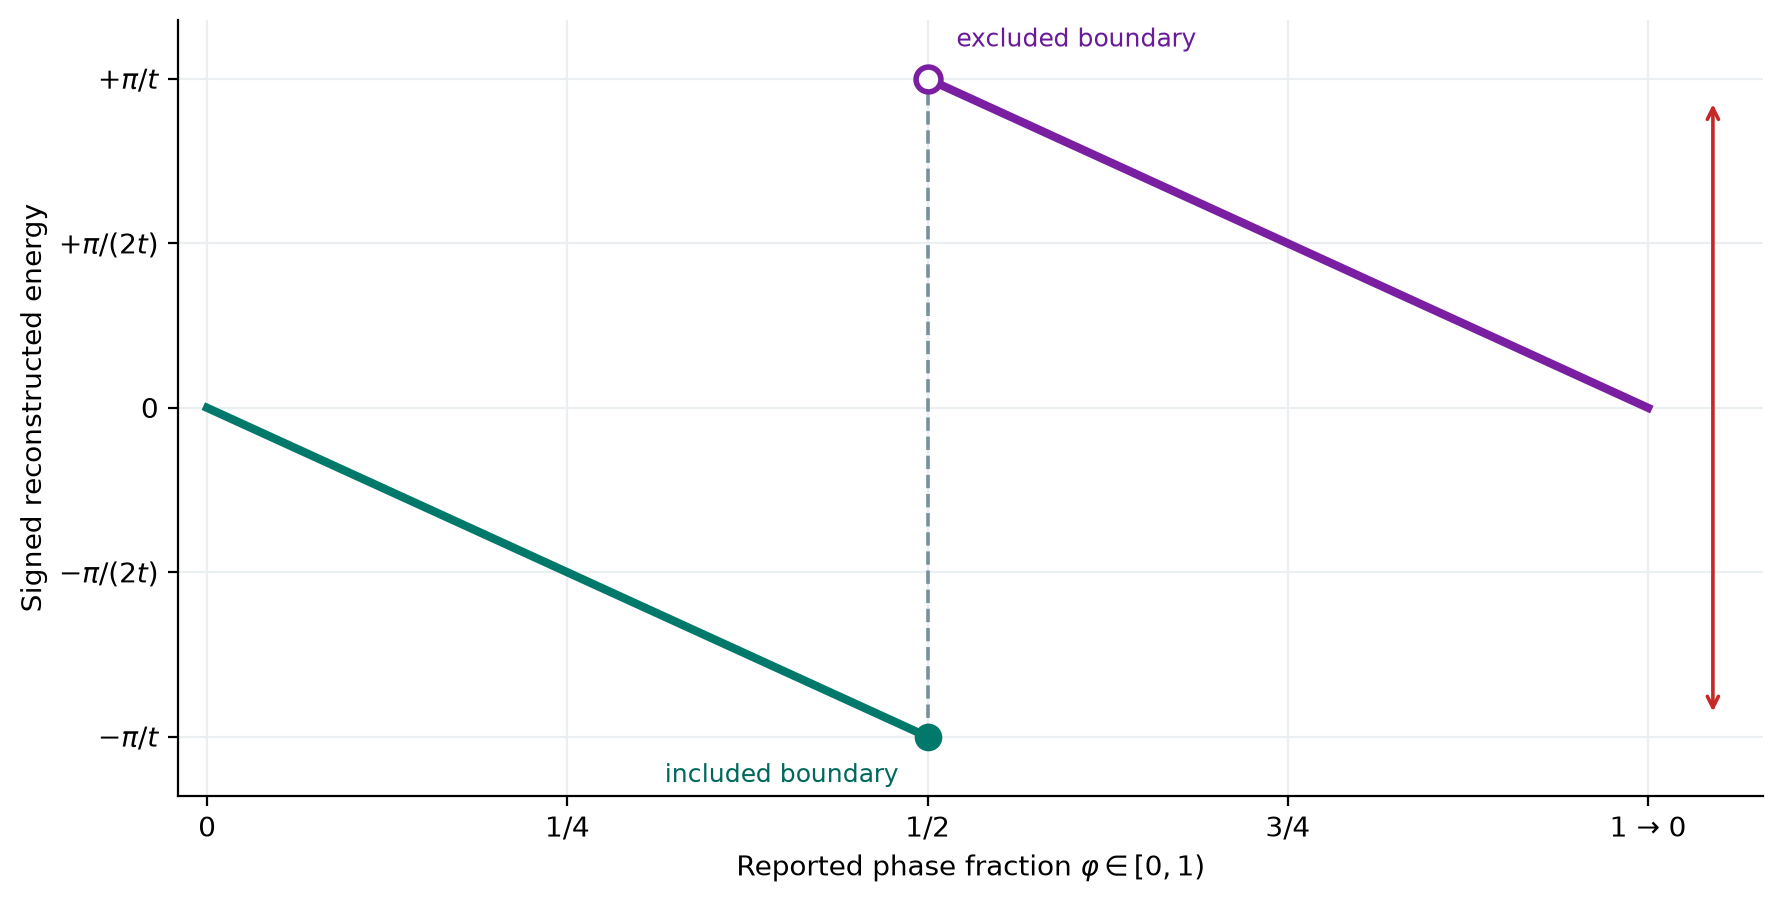

## Qubit measurement and shots

Immediately before measurement, the readout ancilla has a state

$$
\vert q\rangle
=\gamma_0\vert0\rangle+\gamma_1\vert1\rangle,
\qquad
|\gamma_0|^2+|\gamma_1|^2=1.
$$

The coefficients $\gamma_0$ and $\gamma_1$ are complex probability amplitudes.
They play the same mathematical role as the determinant coefficients $c_I$ and eigenstate amplitudes $a_j$ introduced earlier, but here they describe the two computational-basis states of one qubit.

Measuring this qubit in the computational basis returns one classical bit.
The probability of measuring zero is $|\gamma_0|^2$, and the probability of measuring one is $|\gamma_1|^2$.
One preparation, circuit execution, and measurement is called a *shot*.

A single shot samples one outcome; it does not reveal the probabilities themselves.
Repeating the same circuit from a freshly prepared state produces counts whose relative frequencies estimate the probabilities.
For example, 70 zero outcomes among 100 shots estimate the probability of zero as $0.70$.

In this IQPE implementation, phase kickback, feedback, and the final H gate make the readout-ancilla probabilities depend on the phase bit being measured.
The circuit uses an odd number of shots and selects the majority outcome as that iteration's bit.
It then uses this classical bit to set the feedback rotation for the next iteration.

The loop executes iteration $k=0$ first.
This iteration applies the largest controlled power and estimates the least-significant phase bit.
Later iterations proceed toward the most-significant bit.

## One phase bit at a time

Standard phase estimation uses several readout ancillas and an inverse quantum Fourier transform to obtain a complete phase in one coherent circuit.
The QDK/Chemistry iterative implementation (IQPE) instead reuses a single readout ancilla across a sequence of independently executed circuits.
This reduces each circuit's logical-qubit requirement, both on quantum hardware and in this tutorial's classical simulator, at the cost of repeated state preparation and circuit execution.
This qubit-resource tradeoff is why the tutorial uses IQPE.

For iterations over $k=0,1,\ldots,m-1$, the circuit builder uses the controlled power

$$
U^{2^{m-k-1}}.
$$

With $m=6$, the six iteration circuits therefore apply powers $32,16,8,4,2,1$.
QDK/Chemistry reverses the measurements from execution order when it constructs the conventional most-significant-bit-first result.
For an input eigenstate, the first H gate prepares the readout ancilla in $(\vert0\rangle+\vert1\rangle)/\sqrt{2}$.
The feedback rotation applies a corrective phase determined by earlier iterations.
The controlled power then produces *phase kickback*: the $\vert1\rangle$ branch acquires the eigenphase of $U^{2^{m-k-1}}$, while the $\vert0\rangle$ branch does not.
Together, the feedback and kickback phases cancel the contribution already determined by earlier iterations.
After the second H gate, the remaining relative phase changes the probabilities of measuring zero or one, revealing the next phase bit.

If iteration $k$ selects bit $b_k$, QDK/Chemistry updates its accumulated feedback angle according to

$$
\Phi_{k+1}=\frac{\Phi_k}{2}+\frac{\pi b_k}{2},
\qquad \Phi_0=0.
$$

After the last iteration, the reported phase fraction is $\Phi_m/\pi$.
The following figure summarizes one iteration, from fresh register preparation through repeated shots, majority voting, and the feedback update for the next phase bit.

<div style="text-align:center;">

![Flow through one IQPE iteration. In parallel, freshly prepare the molecular trial state on the compute register and a Hadamard superposition on a new readout ancilla. Rotate the ancilla using feedback from earlier measured bits, then use it to control this iteration's time-evolution power on the compute register. Apply a final Hadamard gate and measure the ancilla for one shot. Repeat with fresh registers for an odd number of shots; their majority selects phase bit b sub k. Use that bit to update the classical feedback angle and continue to iteration k plus 1.](attachment:tutorial_qpe_iqpe_iteration.png)

*One IQPE iteration estimates phase bit $b_k$. Every shot freshly prepares the trial state and readout ancilla; the majority outcome updates $\Phi_{k+1}=\Phi_k/2+\pi b_k/2$ for the next controlled power.*

</div>

After all iterations, the feedback accumulator determines the final phase fraction.

Each iteration circuit contains twelve compute qubits and one readout ancilla, for thirteen logical qubits in the simulated circuit.
The readout ancilla does not represent an additional molecular spin orbital.

<div style="border-left:4px solid #8c4a00;background:#8c4a001a;border-radius:4px;margin:1em 0;"><details><summary style="background:#8c4a00;color:#ffffff;padding:0.35em 0.8em;cursor:pointer;font-weight:600;">&#10067;&nbsp;Why is trial-state preparation included in every IQPE iteration circuit?</summary>

<div style="padding:0.1em 1em;">

Each phase bit is measured by executing a separate circuit, and every shot begins with newly allocated qubits in the all-zero state.
The state-preparation logical circuit must therefore reload the trial state before each controlled evolution.

</div>

</details></div>

The script configures the native iterative circuit builder and first-order Trotter unitary through nested `AlgorithmRef` objects:
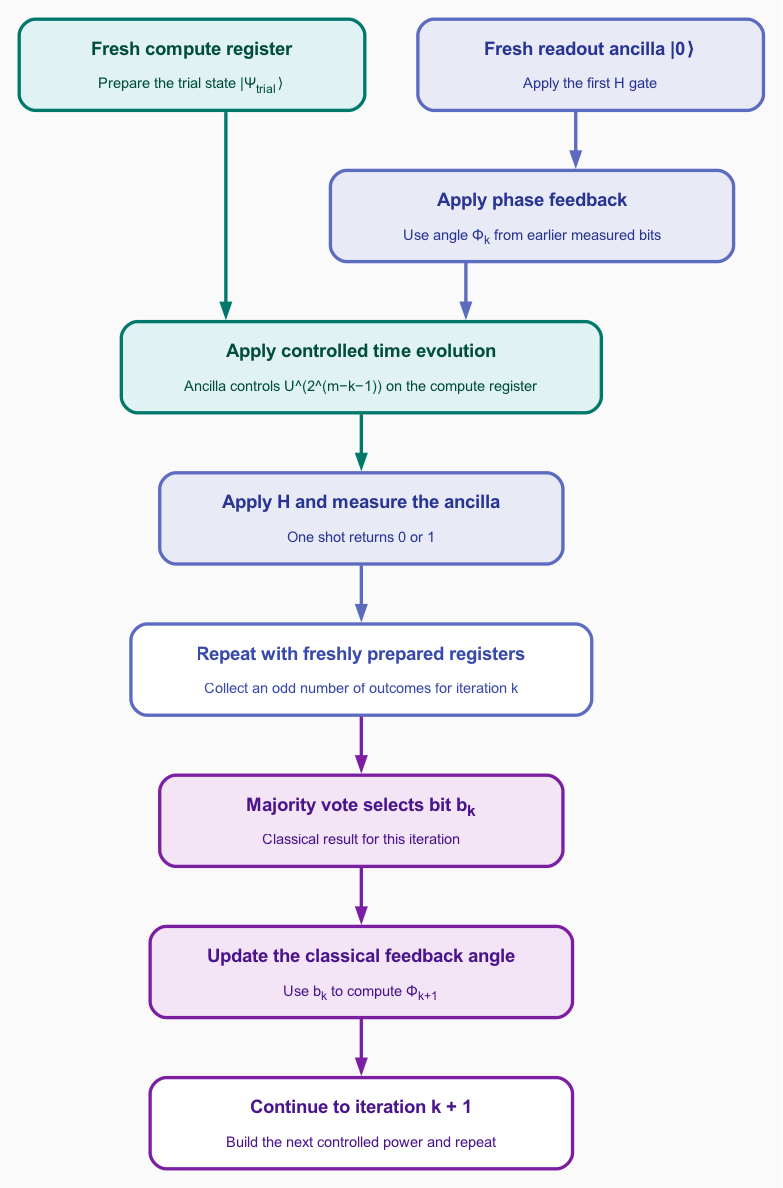

In [ ]:
def iqpe_circuit_builder_reference(
    evolution_time_hartree_inverse: float,
    *,
    num_phase_bits: int = DEFAULT_NUM_PHASE_BITS,
) -> AlgorithmRef:
    """Describe native IQPE with repeated first-order Trotter evolution.

    Args:
        evolution_time_hartree_inverse: Base simulated time in inverse Hartree.
        num_phase_bits: Iteration count and number of reported binary phase places.

    Returns:
        A nested algorithm reference selecting the native iterative builder,
        Pauli-sequence controlled-circuit mapping, one first-order Trotter
        division, and repeated base-unitary powers.
    """
    return AlgorithmRef(
        "qpe_circuit_builder",
        "qdk_iterative",
        num_bits=num_phase_bits,
        controlled_circuit_mapper=AlgorithmRef(
            "controlled_circuit_mapper", "pauli_sequence"
        ),
        unitary_builder=AlgorithmRef(
            "hamiltonian_unitary_builder",
            "trotter",
            time=evolution_time_hartree_inverse,
            order=1,
            num_divisions=1,
            power_strategy="repeat",
        ),
    )

## Numerical controls

Five controls determine the approximation and sampling behavior of this workflow:

- ***Evolution time***
  The value $t$ sets the signed energy interval and spacing of the phase grid, as described above.
  Here it is tuned with the known classical reference to produce a $1\ \mathrm{m}E_{\mathrm{h}}$ grid error.
- ***Hamiltonian simulation***
  The qubit Hamiltonian is a sum of Pauli terms that generally do not commute.
  A first-order [Trotter product formula](https://en.wikipedia.org/wiki/Lie_product_formula) approximates evolution under that sum by applying the exponential of each Pauli term in sequence.
  For $\hat H=\sum_\ell h_\ell P_\ell$, using $r$ Trotter divisions gives

$$
e^{-i\hat Ht}
\approx
\left[\prod_\ell e^{-ih_\ell P_\ell t/r}\right]^r.
$$

  One division ($r=1$) is used for each base evolution in this tutorial.
  Increasing $r$ shortens each simulated time step and generally reduces product-formula error, but repeats the Pauli-term sequence more times and increases circuit cost.
  The repeated-power strategy implemented by QDK/Chemistry constructs each controlled power $U^{2^{m-k-1}}$ by repeating that same approximate base unitary, preserving one consistent approximation across the IQPE iterations.
- ***Phase bits***
  Six bits produce six iteration circuits and $2^6=64$ representable phase fractions.
  Increasing this count refines the grid but causes the largest controlled power, circuit size, and simulator runtime to grow exponentially for the repeated-power strategy.
- ***Shots per bit***
  Each iteration circuit is executed three times.
  The odd shot count prevents a tied bit vote, but finite sampling can still select the less probable bit.
- ***Complete runs***
  The full six-bit procedure is repeated twenty times with simulator seeds 42 through 61.
  Each complete run returns one reconstructed bitstring and energy, and the final estimate uses the most frequent complete bitstring.

The default workflow therefore executes $6\times3\times20=360$ iteration-circuit shots.
Phase-grid error, Trotter error, and sampling variation have different causes and should not be combined with basis-set or active-space model error.

<div style="border-left:4px solid #8c4a00;background:#8c4a001a;border-radius:4px;margin:1em 0;"><details><summary style="background:#8c4a00;color:#ffffff;padding:0.35em 0.8em;cursor:pointer;font-weight:600;">&#10067;&nbsp;Which control changes energy-grid spacing without changing the molecular Hamiltonian?</summary>

<div style="padding:0.1em 1em;">

The number of phase bits changes how finely the phase interval is discretized.
The evolution time also rescales the grid in energy units, but it simultaneously changes the unaliased energy interval and the simulated evolution.

</div>

</details></div>

## IQPE circuit visualization

The cells below build the six iteration circuits and render the shortest one. No quantum simulation runs here.

<div style="text-align:center;">

![Overview of the power-one IQPE circuit on thirteen wires. The top wire is the readout ancilla and receives an H gate, an Rz feedback rotation labeled zero, the controlled Pauli-evolution block, a final H gate, and measurement and reset. The remaining twelve wires form the compute register. State-preparation blocks act on the compute wires that require preparation operations, the controlled Pauli-evolution block spans the ancilla and compute register, and reset operations return the compute wires to zero after evolution.](attachment:tutorial_qpe_power_one_circuit_overview.png)

*Overview of the rendered power-one iteration circuit. Dashed outlines mark the nested `MakeIQPECircuit` and `RunIQPE` Q# operations; the solid boxes show their principal composite operations.*

</div>

The top wire, $\lvert\psi_0\rangle$, is readout ancilla q0.
Its first H gate creates a superposition, and the `Rz(0.0000)` block applies the phase-feedback rotation.
This static preview constructs all six circuits with the builder's initial feedback angle of zero, so the displayed rotation is zero.
During an actual IQPE run, each iteration circuit is rebuilt using the accumulated feedback from earlier measured bits; the power-one iteration can therefore have a nonzero feedback rotation.

The lower wires, $\lvert\psi_1\rangle$ through $\lvert\psi_{12}\rangle$, are compute-register qubits q1–q12.
The `StatePreparation` blocks load the four-determinant trial state on the subsets of compute wires that require preparation operations; blank wires remain part of the compute register.
The `RepControlledPauliExp` block is the power-one controlled first-order Trotter evolution.
The ancilla controls this block, and the resulting phase kickback places the Hamiltonian eigenphase on the ancilla's relative phase.
The final H gate converts that relative phase into measurement probabilities, the measurement produces one shot outcome, and the blue reset operations return the allocated qubits to $\lvert0\rangle$.

<div style="border-left:4px solid #8c4a00;background:#8c4a001a;border-radius:4px;margin:1em 0;"><details><summary style="background:#8c4a00;color:#ffffff;padding:0.35em 0.8em;cursor:pointer;font-weight:600;">&#10067;&nbsp;How can you identify the readout ancilla in the rendered circuit?</summary>

<div style="padding:0.1em 1em;">

The q0 wire receives the H gates and feedback rotation, controls the Hamiltonian evolution, and is measured to obtain the phase bit.
The other twelve wires hold the prepared molecular state and form the compute register.

</div>

</details></div>

<div style="border-left:4px solid #8c4a00;background:#8c4a001a;border-radius:4px;margin:1em 0;"><details><summary style="background:#8c4a00;color:#ffffff;padding:0.35em 0.8em;cursor:pointer;font-weight:600;">&#10067;&nbsp;Why do all six iteration circuits have the same width but different lengths?</summary>

<div style="padding:0.1em 1em;">

Every iteration uses the same twelve-qubit compute register and one readout ancilla, so each circuit has thirteen logical qubits.
Different controlled powers repeat the approximate time-evolution unitary different numbers of times, changing the logical gate count rather than the register size.

</div>

</details></div>
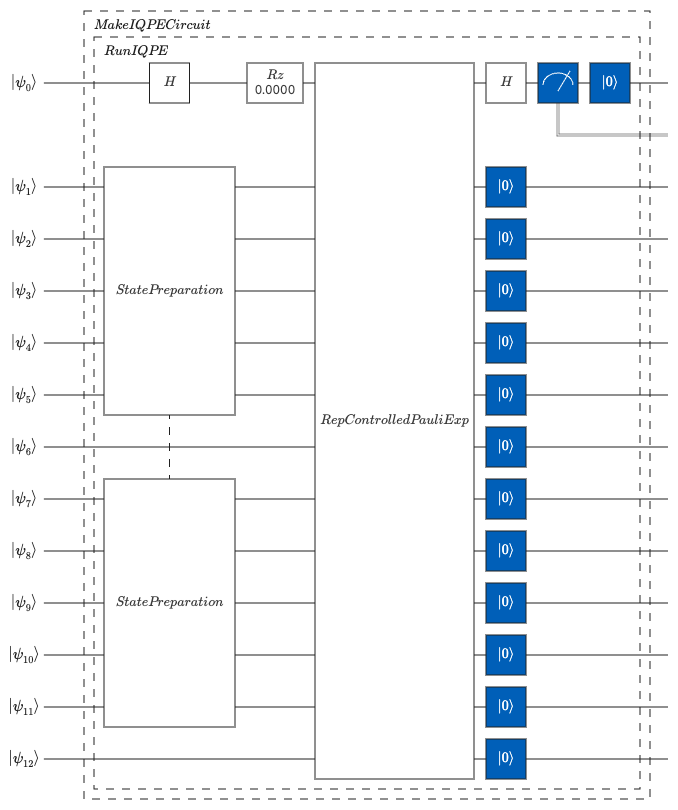

In [ ]:
import json

from IPython.display import Markdown, display
from qdk.widgets import Circuit

problem = prepare_iqpe_problem()

circuit_powers = [32, 16, 8, 4, 2, 1]

circuit_rows = [
    (power, *circuit_statistics(circuit)[:2])
    for power, circuit in zip(
        circuit_powers, problem.iteration_circuits, strict=True
    )
]

table_rows = [
    "| Controlled power | Logical qubits | Decomposed logical gates |",
    "|---:|---:|---:|",
]

for power, qubits, gates in circuit_rows:
    table_rows.append(f"| {power} | {qubits} | {gates:,} |")

display(Markdown("\n".join(table_rows)))

shortest_circuit = problem.iteration_circuits[-1]
num_qubits, num_gates, gate_counts = circuit_statistics(shortest_circuit)

## Register roles

The circuit viewer numbers wires from top to bottom:

- **q0** is the readout ancilla. Its H gates, feedback rotation, controlled evolution, and measurement extract one phase bit.
- **q1 to q12** are the compute register. They hold the encoded molecular trial state and receive the controlled Hamiltonian evolution.

The readout ancilla is algorithm workspace; it is not a thirteenth molecular spin orbital.

## Render the shortest circuit

The complete decomposed circuit is long because it contains one state preparation and one controlled first-order Trotter sequence for a 247-term Hamiltonian. Use the viewer's pan and zoom controls to inspect the ancilla operations and the controlled gates connecting q0 to the compute register.

In [ ]:
display(Circuit(shortest_circuit.get_qsharp_circuit()))

## Iterative phase estimation

The script prepares the mapped Hamiltonian and four-determinant trial state, applies the reference-guided evolution-time choice, and constructs all six iteration circuits before starting any simulation.
This separation lets you inspect settings and circuit counts without accidentally repeating the expensive calculation.

The shortest iteration circuit uses controlled $U$ rather than a higher repeated power.
It still contains the state-preparation operations, twelve-wire compute register, one-wire readout ancilla, feedback rotation, controlled Trotter evolution, and ancilla measurement shared by every iteration.
The companion Jupyter notebook introduced below renders this circuit without simulating it.

One complete IQPE run then invokes the native phase-estimation algorithm with one simulator seed:

In [ ]:
def run_complete_iqpe(problem: IqpeProblem, *, seed: int) -> IqpeRun:
    """Execute one complete bitwise IQPE run with a reproducible simulator seed.

    Args:
        problem: Shared Hamiltonian, trial state, phase controls, and builder setup.
        seed: Full-state simulator seed controlling all finite-shot measurements.

    Returns:
        Canonical bitstring, reconstructed active/total energies, reference error,
        and simulator runtime for one complete phase estimate.
    """
    iqpe = create(
        "phase_estimation",
        "qdk_iterative",
        shots_per_bit=problem.shots_per_bit,
    )
    iqpe.settings().set("qpe_circuit_builder", problem.circuit_builder_reference)
    iqpe.settings().set(
        "circuit_executor",
        AlgorithmRef("circuit_executor", "qdk_full_state_simulator", seed=seed),
    )

    start = perf_counter()
    result = iqpe.run(
        state_preparation=problem.trial_state.circuit,
        qubit_hamiltonian=problem.mapping.qubit_hamiltonian,
    )
    runtime_seconds = perf_counter() - start

    # IQPE measures bits in implementation iteration order. Reconstruct the grid
    # integer from the final phase fraction, then format conventional MSB-first
    # binary so bitstring positions have their familiar place values.
    grid_size = 2**problem.num_phase_bits
    grid_index = round(result.phase_fraction * grid_size) % grid_size
    bitstring = f"{grid_index:0{problem.num_phase_bits}b}"

    # Phase estimation returns the active qubit-Hamiltonian eigenvalue. Add the
    # nuclear/frozen-orbital core term omitted during mapping, then compare with
    # CASCI for exactly the same selected Hamiltonian.
    total_energy = result.raw_energy + problem.mapping.core_energy
    energy_error = total_energy - problem.mapping.active_space_result.refined_energy
    return IqpeRun(
        seed=seed,
        bitstring=bitstring,
        phase_fraction=result.phase_fraction,
        active_energy_hartree=result.raw_energy,
        total_energy_hartree=total_energy,
        error_hartree=energy_error,
        runtime_seconds=runtime_seconds,
    )

Each iteration contributes one measured phase bit to the complete IQPE result.

<div style="border-left:4px solid #8c4a00;background:#8c4a001a;border-radius:4px;margin:1em 0;"><details><summary style="background:#8c4a00;color:#ffffff;padding:0.35em 0.8em;cursor:pointer;font-weight:600;">&#10067;&nbsp;How does IQPE use the result from each iteration to construct the final bitstring and phase fraction?</summary>

<div style="padding:0.1em 1em;">

The majority measurement for one iteration selects a phase bit, which updates the classical phase feedback used by the next iteration.
After all six iterations, the feedback calculation combines the measured bits into one phase fraction.
The script writes that fraction as a conventional six-bit string, with the most significant bit first.

</div>

</details></div>

## Repeated complete runs

One complete run can differ from another because every phase bit is selected from a finite number of simulator shots and the trial state contains several Hamiltonian eigenstates.
The workflow therefore repeats the complete six-bit procedure with twenty deterministic simulator seeds.

The final aggregation rule selects the most frequent complete bitstring, or *mode*.
This differs from the majority vote used inside one complete run: a per-bit majority chooses one bit from three shots, whereas the complete-run mode chooses one reconstructed bitstring from twenty runs.
If several bitstrings tie for the highest count, the script reports that no unique mode exists instead of silently choosing one.

<div style="border-left:4px solid #8c4a00;background:#8c4a001a;border-radius:4px;margin:1em 0;"><details><summary style="background:#8c4a00;color:#ffffff;padding:0.35em 0.8em;cursor:pointer;font-weight:600;">&#10067;&nbsp;Why should the final aggregation use complete bitstrings rather than vote on each bit across complete runs?</summary>

<div style="padding:0.1em 1em;">

Each complete bitstring represents one phase-grid point and its corresponding energy.
Voting independently on bits could assemble a bitstring that was never produced by any complete run and would discard the observed joint distribution.

</div>

</details></div>

## Molecular energy reconstruction

After the repeated complete runs, the script selects the bitstring observed most often.
Interpret this bitstring as a binary integer $b$.
If the calculation measures $m$ phase bits, convert $b$ to the phase fraction

$$
\varphi=\frac{b}{2^m}.
$$

QDK/Chemistry converts $2\pi\varphi$ to its equivalent signed angle $\alpha$ between $-\pi$ and $\pi$.
Negating that angle and dividing by the evolution time maps the measured phase to the active-space energy:

$$
E_{\mathrm{active}}^{\mathrm{IQPE}}=\frac{-\alpha}{t}.
$$

This estimates an eigenvalue of the qubit Hamiltonian, not yet the selected-space molecular total.
Finite phase resolution, sampling, and product-formula time evolution all contribute error.
As *Mapping the problem to qubits* explains, the mapper does not include the core energy in the qubit Hamiltonian.
The core energy contains the nuclear repulsion and the constant contribution from frozen inactive orbitals.
Because these contributions are not measured by phase estimation, the script adds them classically:

$$
E_{\mathrm{total}}^{\mathrm{IQPE}}
=E_{\mathrm{active}}^{\mathrm{IQPE}}+E_{\mathrm{core}}.
$$

Finally, compare this reconstructed total with the CASCI energy of the same selected-space Hamiltonian:

$$
\Delta E_{\mathrm{algorithm}}
=E_{\mathrm{total}}^{\mathrm{IQPE}}-E_{\mathrm{CASCI}}.
$$

The workflow meets the teaching target when $\lvert\Delta E_{\mathrm{algorithm}}\rvert\leq1\ \mathrm{m}E_{\mathrm{h}}$.
This comparison evaluates the configured quantum algorithm against its classical reference; it does not measure basis-set or active-space model error.

<div style="border-left:4px solid #8c4a00;background:#8c4a001a;border-radius:4px;margin:1em 0;"><details><summary style="background:#8c4a00;color:#ffffff;padding:0.35em 0.8em;cursor:pointer;font-weight:600;">&#10067;&nbsp;Which energy comparison determines whether the IQPE workflow meets the teaching target?</summary>

<div style="padding:0.1em 1em;">

Compare the reconstructed IQPE total energy with the CASCI energy of the same selected active-space Hamiltonian.
Comparing with experiment or a larger orbital space would mix algorithmic error with model error.

</div>

</details></div>

## Read a phase off the grid

Each complete run returns a six-bit string. That string is the binary representation of a grid index $k$, and the estimated phase is $\varphi_k = k / 2^{6}$.

Complete `measured_phase` so it converts the measured bitstring into its phase fraction.

In [ ]:
from _unit import exercise

measured_bitstring = "010000"


@exercise
def measured_phase():
    return 0.0

**Hint**

`int(measured_bitstring, 2)` reads a binary string as an integer. The grid has $2^{n}$ points for `n` bits, and `len(measured_bitstring)` gives you `n`.

**Solution**

```python
@exercise
def measured_phase():
    return int(measured_bitstring, 2) / 2 ** len(measured_bitstring)
```

The selected grid point `010000` is $k=16$, so $\varphi = 16/64 = 0.25$.

## The complete workflow

The cell below runs the complete workflow. It is the long step in this chapter and reports progress after each complete run.

The script prints its settings before simulation and reports progress for every complete run, including the seed, bitstring, total energy, error, and elapsed time.
A successful run completes all twenty runs and prints the complete-run bitstring counts, most frequent bitstring, component energies, reconstructed total, reference energy, and signed error.

<div style="border-left:4px solid #8c4a00;background:#8c4a001a;border-radius:4px;margin:1em 0;"><details><summary style="background:#8c4a00;color:#ffffff;padding:0.35em 0.8em;cursor:pointer;font-weight:600;">&#10067;&nbsp;What bitstring distribution and energy estimate did the script produce?</summary>

<div style="padding:0.1em 1em;">

The bitstring `010000` appeared 19 times and `001111` appeared once, so `010000` was the most frequent result.
It produced an active-space energy of $-9.652276065987\ E_{\mathrm{h}}$ and a reconstructed total of $-108.770051792909\ E_{\mathrm{h}}$ after adding the core energy.

</div>

</details></div>

<div style="border-left:4px solid #8c4a00;background:#8c4a001a;border-radius:4px;margin:1em 0;"><details><summary style="background:#8c4a00;color:#ffffff;padding:0.35em 0.8em;cursor:pointer;font-weight:600;">&#10067;&nbsp;Does the result meet the teaching target, and what does that establish?</summary>

<div style="padding:0.1em 1em;">

The reconstructed total is $+1\ \mathrm{m}E_{\mathrm{h}}$ above the selected-space CASCI reference, meeting the teaching target at its boundary.
That offset was deliberately set by the reference-guided phase-grid alignment, while Trotter approximation and finite sampling can still affect which bitstring is selected.
This classical simulation of the quantum calculation therefore validates this configured teaching workflow; it does not remove molecular-model error or establish agreement with experiment.

</div>

</details></div>

Record all settings, bitstring counts, energies, error, and observed runtime in the *phase-estimation section of the lab notebook*.
Then complete the *conclusion* by separating basis-set, active-space, and quantum-algorithm limitations.

In [ ]:
iqpe_result = run_iqpe_workflow()
print_iqpe_results(iqpe_result)

## Knowledge check

<div style="border-left:4px solid #8c4a00;background:#8c4a001a;border-radius:4px;margin:1em 0;"><details><summary style="background:#8c4a00;color:#ffffff;padding:0.35em 0.8em;cursor:pointer;font-weight:600;">&#10067;&nbsp;What changes if the number of phase bits increases while the repeated-power strategy remains fixed?</summary>

<div style="padding:0.1em 1em;">

The phase grid becomes finer, but an additional iteration circuit is required and the largest controlled-unitary power doubles.
For repeated-power Trotter evolution, that larger power increases circuit size and simulator runtime substantially.

</div>

</details></div>

<div style="border-left:4px solid #8c4a00;background:#8c4a001a;border-radius:4px;margin:1em 0;"><details><summary style="background:#8c4a00;color:#ffffff;padding:0.35em 0.8em;cursor:pointer;font-weight:600;">&#10067;&nbsp;Would increasing shots per bit make the phase grid finer?</summary>

<div style="padding:0.1em 1em;">

No.
More shots can make each bit majority more stable, but grid spacing is controlled by the evolution time and number of phase bits.

</div>

</details></div>

## What you accomplished

You completed an end-to-end molecular-energy workflow: defining stretched N<sub>2</sub> in an orbital basis, selecting an active space, mapping its Hamiltonian to qubits, preparing a multiconfigurational trial state, simulating iterative phase estimation, and reconstructing the molecular total energy by adding the core energy.

The final comparison shows that this configured IQPE workflow reproduces the matching selected-space CASCI reference within the tutorial's $1\ \mathrm{m}E_{\mathrm{h}}$ target.

Your lab notebook records where those choices enter and what evidence supports the result.
A useful next investigation would change one layer at a time: enlarge the molecular model, choose a different trial state, or vary the phase-estimation controls, then identify which accuracy and cost measures respond.

## Further reading

- *Phase estimation*
- *Phase-estimation circuit builders*
- *Hamiltonian unitary builders*
- *Circuit execution*
- *Phase-estimation results*